# PRÁCTICA 2 PLN
# Desarrollo de una aplicación de Procesamiento del Lenguaje Natural

Alumnos:

Javier García Fernández

Miguel Ángel Véliz Ayala

# 3. Búsqueda de hilos similares

In [ ]:
pip install fasttext numpy matplotlib scikit-learn tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 1.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-2.13.6-py3-none-any.whl.metadata (9.5 kB)
Using cached pybind11-2.13.6-py3-none-any.whl (243 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp311-cp311-linux_x86_64.whl size=4313503 sha256=fbf7b53915e1df81a661b0e052a3ee7a88699ea8ab7b1ab5eca2af6dac0062c3
  Stored in directory: /root/.cache/pip/wheels/65/4f/35/5057db0249224e9ab55a513fa6b79451473ceb7713017823c3
Successfully built fasttext


In [ ]:
pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import fasttext
import fasttext.util
import warnings
warnings.filterwarnings('ignore')
import re
from collections import defaultdict

In [ ]:
# Intentar importar sentence-transformers (para la parte adicional)
try:
    from sentence_transformers import SentenceTransformer
    sentence_transformers_available = True
except ImportError:
    print("Sentence-transformers no está instalado. Solo se usará fastText.")
    sentence_transformers_available = False

In [ ]:
# Función para cargar los archivos JSON
def load_json_files():
    data = {}
    json_files = [
        'comments_cricket.json',
        'comments_formula1.json',
        'comments_hockey.json',
        'comments_nba.json',
        'comments_nfl.json',
        'comments_soccer.json',
        'comments_sports.json'
    ]

    for file_name in json_files:
        subreddit = file_name.replace('comments_', '').replace('.json', '')
        try:
            with open(file_name, 'r', encoding='utf-8') as f:
                data[subreddit] = json.load(f)
            print(f"Cargado {file_name}: {len(data[subreddit])} hilos")
        except FileNotFoundError:
            print(f"Advertencia: No se encontró el archivo {file_name}")

    return data

# Función para preprocesar texto
def preprocess_text(text):
    # Convertir a minúsculas
    text = text.lower()
    # Eliminar URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '<URL>', text, flags=re.MULTILINE)
    # Eliminar caracteres especiales manteniendo letras, números y espacios
    text = re.sub(r'@\w+', '<USER>', text)
    # Eliminar números
    text = re.sub(r'\d+', '<NUM>', text)
    # Eliminar todos los caracteres que no sean letras, números o espacios
    text = re.sub(r'[^\w\s]', '', text)
    # Reemplazar múltiples espacios por uno solo
    text = re.sub(r'\s+', ' ', text)
    # Eliminar espacios al inicio y final
    text = text.strip()
    return text

In [ ]:
# Función para concatenar comentarios de un hilo
def concatenate_thread_comments(thread):
    comments_text = []
    for comment in thread['comments']:
        comments_text.append(comment['comment'])

    # Añadir también el título y la descripción para capturar mejor el contenido del hilo
    full_text = thread['title'] + " " + thread['description'] + " " + " ".join(comments_text)
    return preprocess_text(full_text)

In [ ]:
# Función para cargar o descargar el modelo de fastText
# También aprovechamos para devolver el modelo recien descargado
def load_fasttext_model():
    print("Cargando modelo de fastText...")

    # Intentar cargar el modelo si ya existe
    model_path = 'cc.en.300.bin'

    if not os.path.exists(model_path):
        print(f"Descargando modelo de fastText...")
        fasttext.util.download_model('en', if_exists='ignore')

    # Cargar el modelo
    model = fasttext.load_model('cc.en.300.bin')
    print("Modelo de fastText cargado.")
    return model

In [ ]:
# Función para obtener embedding de un texto usando fastText
def get_fasttext_embedding(model, text):
    # Si el texto está vacío, devolvemos un vector de ceros
    if not text or len(text.strip()) == 0:
        return np.zeros(model.get_dimension())

    # Dividimos el texto en palabras
    words = text.split()

    # Si no hay palabras, devolvemos un vector de ceros
    if len(words) == 0:
        return np.zeros(model.get_dimension())

    # Obtenemos el embedding de cada palabra y luego promediamos
    word_vectors = [model.get_word_vector(word) for word in words]
    return np.mean(word_vectors, axis=0)

In [ ]:
# Función para calcular similitud entre hilos
# Vamos a usar la similaridad del coseno
def calculate_thread_similarities(embeddings, subreddit_map):
    similarity_matrix = cosine_similarity(embeddings)
    return similarity_matrix

In [ ]:
# Función para visualizar embeddings con t-SNE
def visualize_embeddings(embeddings, subreddit_map, title):
    # Aplicar t-SNE para reducir dimensionalidad a 2D
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embedded = tsne.fit_transform(embeddings)

    # Crear un diccionario que mapee cada subreddit a un color
    subreddits = list(set(subreddit_map))
    colors = plt.cm.rainbow(np.linspace(0, 1, len(subreddits)))
    subreddit_to_color = {subreddit: colors[i] for i, subreddit in enumerate(subreddits)}

    # Crear una figura grande
    plt.figure(figsize=(12, 10))

    # Plotear cada punto
    for i, point in enumerate(embedded):
        subreddit = subreddit_map[i]
        color = subreddit_to_color[subreddit]
        plt.scatter(point[0], point[1], color=color, alpha=0.7)

    # Añadir leyenda
    for subreddit, color in subreddit_to_color.items():
        plt.scatter([], [], color=color, label=f'r/{subreddit}')

    plt.legend(loc='best')
    plt.title(title)
    # En caso de que queramos guardar la figura:
    # plt.savefig(f"{title.replace(' ', '_').lower()}.png")
    # plt.close()
    plt.show()

In [ ]:
# Función para identificar hilos que no encajan con su subreddit
def identify_outliers(similarity_matrix, embeddings, subreddit_map, n_top=5):
    results = {}
    subreddits = list(set(subreddit_map))

    # Para cada subreddit, encontrar los hilos que tienen
    # mayor similitud con hilos de otros subreddits
    for subreddit in subreddits:
        results[subreddit] = []

        # Índices de hilos de este subreddit
        subreddit_indices = [i for i, s in enumerate(subreddit_map) if s == subreddit]

        for idx in subreddit_indices:
            # Obtener similitudes con todos los hilos
            similarities = similarity_matrix[idx]

            # Excluir la similitud consigo mismo
            similarities[idx] = -1

            # Encontrar los índices de los hilos más similares
            most_similar_indices = np.argsort(similarities)[-n_top:][::-1]

            # Contar cuántos de los hilos más similares son de otros subreddits
            other_subreddit_count = sum(1 for i in most_similar_indices if subreddit_map[i] != subreddit)

            # Si la mayoría son de otros subreddits, este hilo podría no encajar bien
            if other_subreddit_count > n_top / 2:
                # Guardar el índice de este hilo como potencial outlier
                results[subreddit].append((idx, other_subreddit_count))

    return results

In [ ]:
# Función principal para ejecutar el análisis con fastText
# Consiste en un análisis completo usando los embeddings de fastText
def run_fasttext_analysis(data):
    # Paso 1: Cargar el modelo de fastText
    model = load_fasttext_model()

    # Paso 2: Preparar datos para embeddings
    all_threads_text = []
    subreddit_map = []
    thread_info = []  # Guardar información adicional de cada hilo

    print("Preparando datos para embeddings...")
    for subreddit, threads in data.items():
        for thread in threads:
            thread_text = concatenate_thread_comments(thread)
            all_threads_text.append(thread_text)
            subreddit_map.append(subreddit)
            thread_info.append({
                'subreddit': subreddit,
                'title': thread['title'],
                'author': thread['author']
            })

    # Paso 3: Generar embeddings con fastText
    print("Generando embeddings con fastText...")
    fasttext_embeddings = np.array([get_fasttext_embedding(model, text) for text in tqdm(all_threads_text)])

    # Paso 4: Calcular similitudes entre hilos
    print("Calculando similitudes entre hilos...")
    similarity_matrix = calculate_thread_similarities(fasttext_embeddings, subreddit_map)

    # Paso 5: Visualizar embeddings
    print("Visualizando embeddings...")
    visualize_embeddings(fasttext_embeddings, subreddit_map, "Embeddings de hilos usando fastText")

    # Paso 6: Identificar outliers
    print("Identificando hilos que no encajan con su subreddit...")
    outliers = identify_outliers(similarity_matrix, fasttext_embeddings, subreddit_map)

    # Mostrar algunos resultados de outliers
    print("\nHilos que potencialmente no encajan con su subreddit:")
    for subreddit, outlier_threads in outliers.items():
        if outlier_threads:
            print(f"\nr/{subreddit}:")
            for idx, other_count in sorted(outlier_threads, key=lambda x: x[1], reverse=True)[:3]:
                print(f"  - {thread_info[idx]['title']} (por {thread_info[idx]['author']})")
                print(f"    {other_count} de los 5 hilos más similares son de otros subreddits")

    return fasttext_embeddings, similarity_matrix, subreddit_map, thread_info

In [ ]:
# Ahora nos queda la función para ejecutar análisis con Sentence-Transformers
def run_sentence_transformers_analysis(data, model_name):
    if not sentence_transformers_available:
        print("No se puede realizar el análisis con Sentence-Transformers porque la biblioteca no está instalada.")
        return None, None, None, None

    print(f"\nEjecutando análisis con el modelo: {model_name}")

    # Paso 1: Cargar el modelo
    try:
        model = SentenceTransformer(model_name)
        print(f"Modelo {model_name} cargado correctamente.")
    except Exception as e:
        print(f"Error al cargar el modelo {model_name}: {e}")
        return None, None, None, None

    # Paso 2: Preparar datos
    all_threads_text = []
    subreddit_map = []
    thread_info = []

    for subreddit, threads in data.items():
        for thread in threads:
            thread_text = concatenate_thread_comments(thread)
            all_threads_text.append(thread_text)
            subreddit_map.append(subreddit)
            thread_info.append({
                'subreddit': subreddit,
                'title': thread['title'],
                'author': thread['author']
            })

    # Paso 3: Generar embeddings
    print("Generando embeddings...")
    st_embeddings = model.encode(all_threads_text, show_progress_bar=True)

    # Paso 4: Calcular similitudes
    print("Calculando similitudes...")
    similarity_matrix = cosine_similarity(st_embeddings)

    # Paso 5: Visualizar
    model_short_name = model_name.split('/')[-1]
    visualize_embeddings(st_embeddings, subreddit_map, f"Embeddings usando {model_short_name}")

    # Paso 6: Identificar outliers
    outliers = identify_outliers(similarity_matrix, st_embeddings, subreddit_map)

    # Mostrar algunos resultados
    print(f"\nHilos que no encajan (según {model_short_name}):")
    for subreddit, outlier_threads in outliers.items():
        if outlier_threads:
            print(f"\nr/{subreddit}:")
            for idx, other_count in sorted(outlier_threads, key=lambda x: x[1], reverse=True)[:3]:
                print(f"  - {thread_info[idx]['title']} (por {thread_info[idx]['author']})")
                print(f"    {other_count} de los 5 hilos más similares son de otros subreddits")

    return st_embeddings, similarity_matrix, subreddit_map, thread_info

In [ ]:
# Función para comparar resultados de diferentes modelos
def compare_model_results(results_dict):
    if len(results_dict) <= 1:
        print("No hay suficientes modelos para comparar.")
        return

    # Calcular solapamiento de outliers entre modelos
    models = list(results_dict.keys())
    print("\n===== Comparación de modelos =====")

    for i in range(len(models)):
        for j in range(i+1, len(models)):
            model1, model2 = models[i], models[j]
            # Usar la thread_info apropiada de cada nodo
            _, _, _, thread_info1 = results_dict[model1]
            _, _, _, thread_info2 = results_dict[model2]

            # Obtener conjuntos de outliers para cada modelo
            outliers1 = set()
            outliers2 = set()

            for subreddit, outlier_threads in results_dict[model1][3].items():
                for idx, _ in outlier_threads:
                    outliers1.add(idx)

            for subreddit, outlier_threads in results_dict[model2][3].items():
                for idx, _ in outlier_threads:
                    outliers2.add(idx)

            # Calcular solapamiento (para en índice de Jaccard)
            intersection = outliers1.intersection(outliers2)
            union = outliers1.union(outliers2)

            if union:
                jaccard_index = len(intersection) / len(union)
                print(f"Solapamiento entre {model1} y {model2}: {len(intersection)} hilos comunes")
                print(f"Índice de Jaccard: {jaccard_index:.4f}")





Análisis de similitud de hilos de Reddit usando word embeddings
Cargado comments_cricket.json: 180 hilos
Cargado comments_formula1.json: 180 hilos
Cargado comments_hockey.json: 180 hilos
Cargado comments_nba.json: 180 hilos
Cargado comments_nfl.json: 180 hilos
Cargado comments_soccer.json: 160 hilos
Cargado comments_sports.json: 104 hilos

===== Análisis con fastText =====
Cargando modelo de fastText...
Descargando modelo de fastText...

Modelo de fastText cargado.
Preparando datos para embeddings...
Generando embeddings con fastText...


100%|██████████| 1164/1164 [00:08<00:00, 130.57it/s]


Calculando similitudes entre hilos...
Visualizando embeddings...


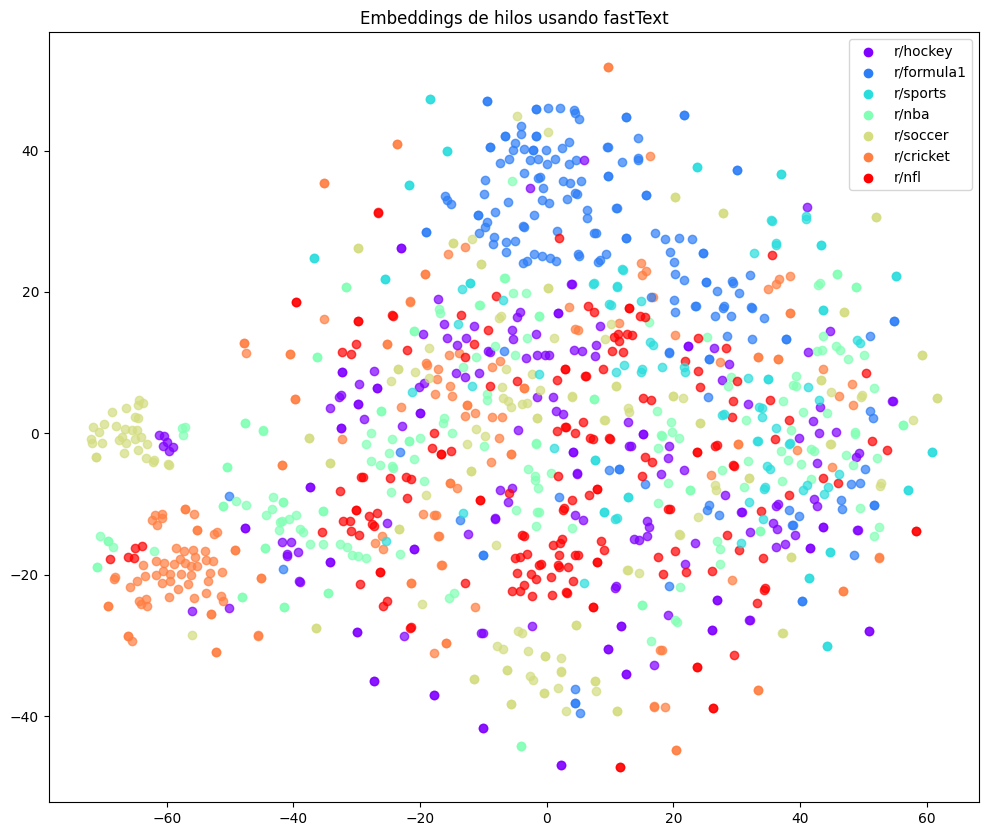

Identificando hilos que no encajan con su subreddit...

Hilos que potencialmente no encajan con su subreddit:

r/hockey:
  - What is going on with the Finnish National Team? (por buerglermeister)
    5 de los 5 hilos más similares son de otros subreddits
  - Looking for unbiased opinions… would you consider this a penalty? (por sjt112486)
    5 de los 5 hilos más similares son de otros subreddits
  - [Chris Johnston] - Not 100% confirmed yet but the expectation seems to be that Game 1 of the Leafs-Panthers series will go Monday night in Toronto. (por Electronic_Nail)
    5 de los 5 hilos más similares son de otros subreddits

r/formula1:
  - Russell p4, Stroll p5, Yuki p6 kimi p7, gasly p8. After 5 second penalty for Lawson, albon and bearman (por Luffy710j)
    5 de los 5 hilos más similares son de otros subreddits
  - Toto Wolff gives his thoughts on Red Bull's Verstappen Antonelli pitlane incident after the 2025 Miami GP Sprint (por ZephyrSonic)
    5 de los 5 hilos más similares so

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo sentence-transformers/all-MiniLM-L6-v2 cargado correctamente.
Generando embeddings...


Batches:   0%|          | 0/37 [00:00<?, ?it/s]

Calculando similitudes...


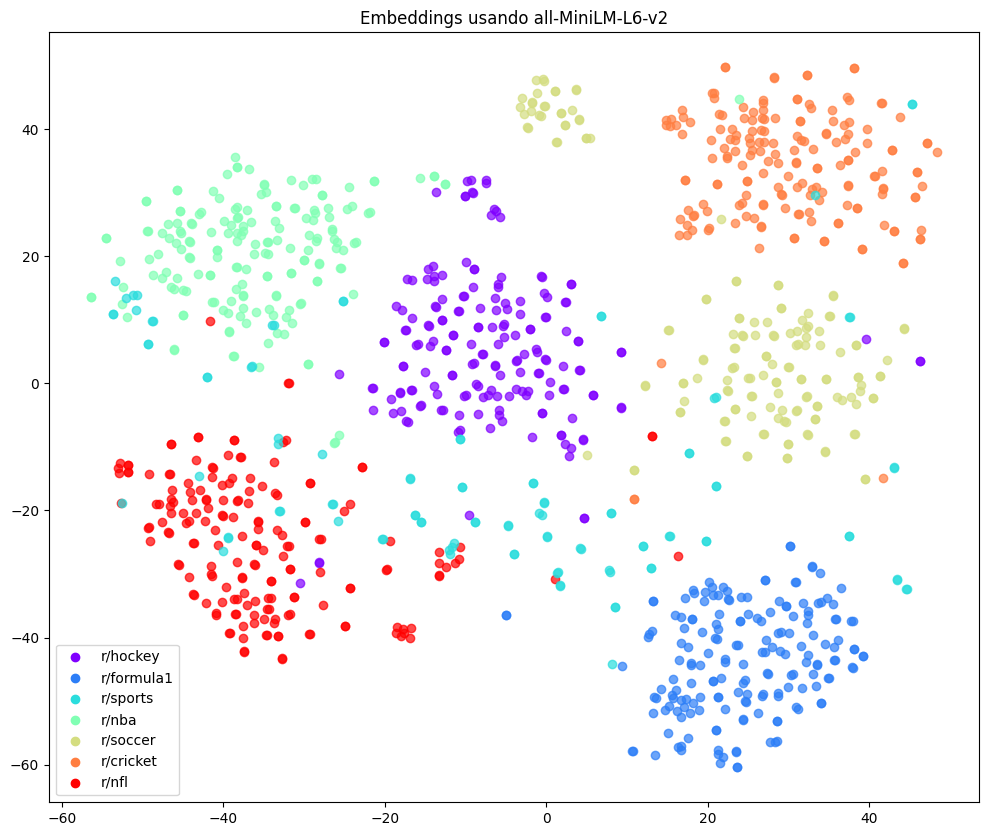


Hilos que no encajan (según all-MiniLM-L6-v2):

r/hockey:
  - Men's World Championship Division IA - situation entering the last day (por DashLibor)
    5 de los 5 hilos más similares son de otros subreddits
  - REPORT: Blake and Hiller Likely to Remain with Kings for 2025-26 Season (por DecentLurker96)
    4 de los 5 hilos más similares son de otros subreddits
  - It looks like Jones wasn't as bad as people think in Florida (por Ok-Environment1821)
    4 de los 5 hilos más similares son de otros subreddits

r/formula1:
  - Max: To see your own little child like that is very special. With my [sister's kids], you hold them & that's very special. But when you're holding your own child that's a step further. In the beginning I felt it was like a packaged chicken in the supermarket so to speak, like the skin... (por OutlandishnessPure2)
    3 de los 5 hilos más similares son de otros subreddits
  - Max: To see your own little child like that is very special. With my [sister's kids], you h

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.4k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo sentence-transformers/all-mpnet-base-v2 cargado correctamente.
Generando embeddings...


Batches:   0%|          | 0/37 [00:00<?, ?it/s]

Calculando similitudes...


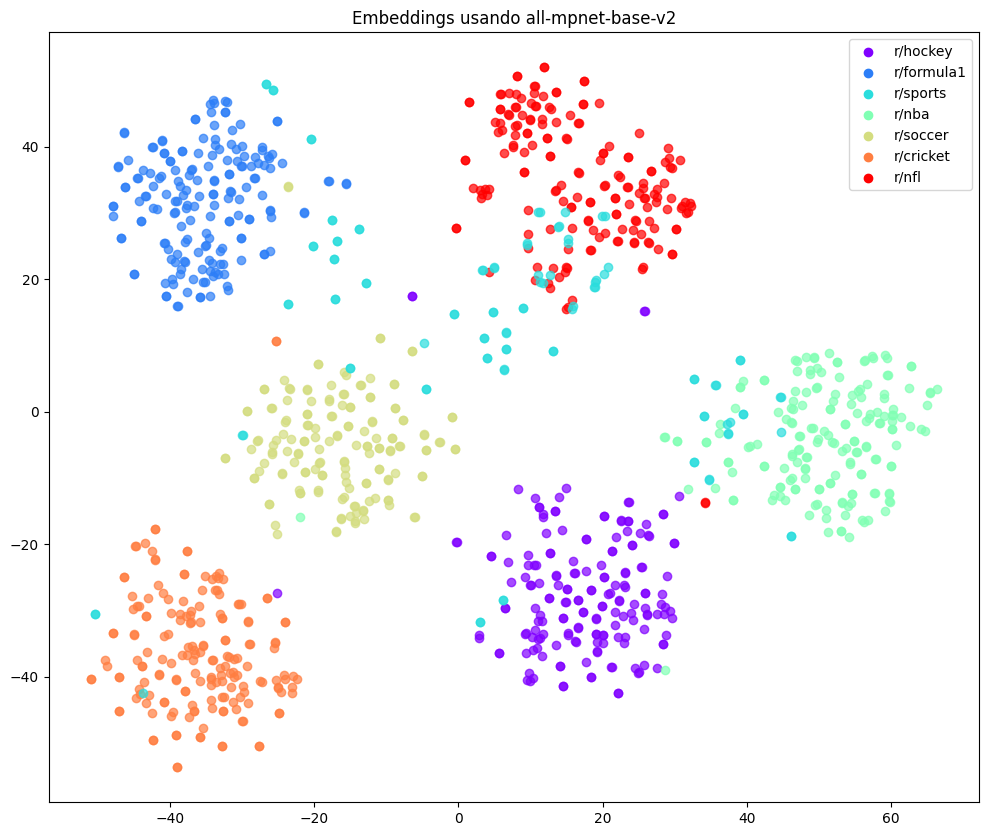


Hilos que no encajan (según all-mpnet-base-v2):

r/hockey:
  - Men's World Championship Division IA - situation entering the last day (por DashLibor)
    5 de los 5 hilos más similares son de otros subreddits
  - It looks like Jones wasn't as bad as people think in Florida (por Ok-Environment1821)
    4 de los 5 hilos más similares son de otros subreddits
  - E.M. says she was ‘completely out of it’ leaving bar with 1 of the world junior players in sex assault trial (por TCGYT)
    4 de los 5 hilos más similares son de otros subreddits

r/sports:
  - 14 year old Vaibhav Suryavanshi has become the youngest player to score an IPL century (100 runs) | RR VS GT | IPL 2025 (por RodrickJasperHeffley)
    5 de los 5 hilos más similares son de otros subreddits
  - Lakers-Timberwolves absurd ending sequence. The "Hawkeye" Camera Overturns the Out of Bounds Call, Ant Sinks the Clutch FTs, and Reaves Misses the 3 to Tie and Timberwolves Lead the Series 3-1 lead over the Lakers. (por Domestiicate

In [ ]:
# Función principal
def main():
    print("\n\n\nAnálisis de similitud de hilos de Reddit usando word embeddings")
    print("=" * 70)

    # Paso 1: Cargar los datos
    data = load_json_files()

    if not data:
        print("No se encontraron archivos de datos. Abortando.")
        return

    # Paso 2: Análisis con fastText
    print("\n===== Análisis con fastText =====")
    fasttext_embeddings, fasttext_similarity, subreddit_map, thread_info = run_fasttext_analysis(data)

    # Guardar los resultados en un diccionario
    results = {
        'fastText': (fasttext_embeddings, fasttext_similarity, subreddit_map, identify_outliers(fasttext_similarity, fasttext_embeddings, subreddit_map))
    }

    # Paso 3: Análisis con sentence-transformers (si está disponible)
    if sentence_transformers_available:
        print("\n===== Análisis con Sentence-Transformers =====")

        # Lista de modelos a probar
        st_models = [
            "sentence-transformers/all-MiniLM-L6-v2",  # Modelo en inglés más ligero
            "sentence-transformers/all-mpnet-base-v2"  # Modelo en inglés más potente
        ]

        # Análisis con cada modelo
        for model_name in st_models:
            embeddings, similarity, subreddit_map, thread_info = run_sentence_transformers_analysis(data, model_name)
            if embeddings is not None:
                model_short_name = model_name.split('/')[-1]
                results[model_short_name] = (embeddings, similarity, subreddit_map, identify_outliers(similarity, embeddings, subreddit_map))

        # Comparar resultados de diferentes modelos
        if len(results) > 1:
            compare_model_results(results)

if __name__ == "__main__":
    main()

Se ha realizado un análisis de similitud temática entre hilos de Reddit pertenecientes a distintos subreddits deportivos, utilizando representaciones vectoriales generadas mediante diferentes modelos de word embeddings. Los subreddits analizados han sido:

- `r/cricket`
- `r/formula1`
- `r/hockey`
- `r/nba`
- `r/nfl`
- `r/soccer`
- `r/sports`

En total, se han procesado 180 hilos, con una distribución equilibrada en la mayoría de subreddits, excepto `r/sports`. Además, también se han generado de forma satisfactoria los embeddings de fastText, all-MiniLM-L6-v2 y all-mpnet-base-v2.

El procedimiento seguido ha sido desarrollado gracias a tres modelos de embeddings:
- `fastText` (basado en n-gramas)
- `all-MiniLM-L6-v2` (tipo Transformer compacto)
- `all-mpnet-base-v2` (Transformer más robusto)

Y a su vez, para cada modelo, hemos hecho:
1. Generación de vectores para cada hilo de Reddit, a partir del texto de los comentarios.
2. Cálculo de similitudes mediante la métrica del coseno.
3. Detección de outliers temáticos: identificación de hilos cuyos 5 vecinos más cercanos pertenecen mayoritariamente a otros subreddits.
4. Visualización del espacio vectorial con proyecciones 2D para observar agrupaciones y dispersiones.


---


A continuación, vamos a evaluar los resultados observados para cada modelo.

- fastText
  - El modelo ha identificado una gran cantidad de hilos fuera de lugar (outliers) en todos los subreddits. Casos extremos se observan en r/hockey, r/nfl y r/formula1, donde algunos hilos tienen sus 5 vecinos más cercanos en subreddits distintos. Aunque esto podría sugerir problemas de precisión, también puede deberse a la naturaleza temática de los hilos. Por ejemplo, temas como la gestión financiera de equipos pueden ser transversales a varios deportes, reduciendo la capacidad de fastText para discriminar por contexto deportivo. La distribución visual en el espacio de embeddings revela una nube densa y dispersa, sin agrupamientos claros por subreddit, lo cual sugiere una representación dudosa y desarrollo del modelo pobre.
  

- all-MiniLM-L6-v2
  - Este modelo muestra un comportamiento más conservador. Aunque también se detectan outliers, estos son menos frecuentes y más coherentes. Visualmente, los hilos tienden a agruparse mejor por temática, y se observa una separación más evidente entre subreddits. r/sports aparece como un nodo disperso, lo cual es razonable dado que es un subreddit generalista y no específico de un deporte.

- all-mpnet-base-v2
  - Este modelo produce resultados similares a los de MiniLM, aunque con ligeras diferencias en los agrupamientos. La agrupación temática en el espacio vectorial es clara, y muestra patrones consistentes con una organización semántica por tipo de deporte.

Una vez evaluados los resultados con cada modelo, queda medirlos para ver su desempeño.

Usando un análisis de la métrica del índice de Jaccard, podemos ver los siguientes resultados:

$$
J(A, B) = \frac{|A \cap B|}{|A \cup B|}
$$

| Modelos comparados | Hilos comunes | Índice de Jaccard |
|--------------|--------------|--------------|
| fastText vs MiniLM | 15 | 0.2542 |
| fastText vs MPNet  | 7  | 0.1207 |
| MiniLM vs MPNet    | 6  | 0.2857 |


El solapamiento entre fastText y los modelos Transformer es bajo, lo que sugiere diferencias significativas en la manera en que representan el contexto y la semántica de los hilos.

El mayor solapamiento se da entre MiniLM y MPNet, con un índice de Jaccard de 0.5652, lo cual es esperable dado que comparten arquitectura y están optimizados para tareas similares.

El solapamiento entre fastText y MPNet es el más bajo (0.0994), lo que puede deberse a las limitaciones del modelo fastText para capturar relaciones semánticas profundas o contexto inter-oracional

Finalmente, si observamos las gráficas, podemos hacernos una idea de la disposición de cada hilo en el espacio de embeddings. En el caso de fastText, no es muy notoria la división entre cada uno, el resultado es más bien una nube de puntos bastante distribuida en el espacio, pero se observan resultados más interesantes con los otros modelos.

Por ejemplo, para MiniLM, podemos observar una agrupación clara entre los subreddits del mismo deporte. También vemos como r/sports no tiene un grupo fijo, lo cual tiene sentido al no ser un deporte como tal y tratar de temas generales. Si nos abstraemos un poco más, podemos incluso dividir (sin contar r/sports) el plano en dos grupos más grandes, aquellos deportes de contacto, como son el hockey, el baloncesto y el fútbol americano y los de no contacto (o considerablemente menos). Observamos algo equivalente, aunque con otra disposición, con el modelo MPNet.

---

A modo de conclusión:
- fastText, aunque útil para análisis rápidos, no capta adecuadamente las relaciones semánticas entre hilos deportivos, y su representación resulta poco estructurada. Es por esto que se suele recomendar únicamente para tareas exploratorias o como punto de partida.

- MiniLM y MPNet ofrecen resultados más precisos y coherentes. Ambos muestran una capacidad razonable para agrupar hilos por deporte, y detectar outliers verdaderos con más precisión.

- MiniLM y MPNet son Transformers preentrenados con arquitectura tipo BERT, que capturan contexto bidireccional y relaciones semánticas profundas entre palabras gracias a su mecanismo de autoatención. Esto les permite representar mejor el significado global de frases y documentos, no solo las palabras individuales. En cambio, fastText representa un texto como la media de embeddings de palabras y subpalabras, sin tener en cuenta el orden ni el contexto en el que aparecen. Esto limita su capacidad para capturar relaciones semánticas complejas


En resumen, para tareas de detección de similitud temática en hilos de Reddit, es mejor optar por modelos como MiniLM o MPNet, que ofrecen una representación semántica más rica y consistente. Esto ha sido validado gracias a dos tipos de análisis: cuantitativo (índice de Jaccard) y cualitativo (visualizaciones) para valorar empíricamente los modelos.